# FlashAttention Ablation Study for YOLOv12 Segmentation

This notebook implements a comprehensive ablation study to quantify the impact of FlashAttention on YOLOv12 segmentation models. We compare models with FlashAttention enabled vs. disabled, measuring inference latency, throughput (FPS), and memory usage on both GPU and CPU platforms.

## Objectives
- Measure latency and throughput differences with/without FlashAttention
- Evaluate performance on GPU (RTX 4060) and CPU platforms
- Determine if models meet the 30 FPS target at 640×480 resolution
- Visualize results with comprehensive matplotlib plots


In [15]:
# Setup and Imports
import sys
import os
import time
import gc
import importlib
from contextlib import contextmanager
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
import seaborn as sns

# Ultralytics imports
try:
    from ultralytics import YOLO
    from ultralytics.utils.metrics import SegmentMetrics
    from ultralytics.nn.modules import block
except ImportError as e:
    print("=" * 80)
    print("ERROR: ultralytics module not found!")
    print("=" * 80)
    print("\nThis project requires ultralytics to be installed from the local source.")
    print("Please:")
    print("1. Run the installation cell above, OR")
    print("2. Run in terminal: cd /home/tiehangz/proj/yolov12 && pip install -e .")
    print("3. Restart the kernel after installation")
    print("\n" + "=" * 80)
    raise

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 8)
rcParams['font.size'] = 11
sns.set_palette("husl")

# Device detection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cuda_available = torch.cuda.is_available()
if cuda_available:
    device_name = torch.cuda.get_device_name(0)
    device_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA Available: {cuda_available}")
    print(f"Device: {device_name}")
    print(f"Compute Capability: {device_capability}")
    print(f"FlashAttention Support: {device_capability[0] >= 8}")
else:
    print("CUDA Not Available - Running on CPU")
    device_name = "CPU"
    device_capability = None

print(f"\nPyTorch Version: {torch.__version__}")
print(f"Current FlashAttention Status: {block.USE_FLASH_ATTN}")


CUDA Available: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU
Compute Capability: (8, 9)
FlashAttention Support: True

PyTorch Version: 2.9.0+cu128
Current FlashAttention Status: True


## FlashAttention Toggle Mechanism

We need a way to dynamically toggle FlashAttention on/off for ablation studies. This context manager allows us to temporarily override the `USE_FLASH_ATTN` flag.


In [16]:
@contextmanager
def toggle_flash_attention(enabled=True):
    """
    Context manager to temporarily override USE_FLASH_ATTN flag.
    
    Args:
        enabled (bool): Whether to enable FlashAttention (True) or disable it (False)
    
    Note: This modifies the module-level variable. Models loaded after entering
    the context will use the new setting. Existing models may need to be reloaded.
    """
    original_value = block.USE_FLASH_ATTN
    try:
        block.USE_FLASH_ATTN = enabled
        # Reload the module to ensure changes take effect
        importlib.reload(block)
        print(f"FlashAttention {'ENABLED' if enabled else 'DISABLED'}")
        yield
    finally:
        block.USE_FLASH_ATTN = original_value
        importlib.reload(block)
        print(f"FlashAttention restored to original state: {original_value}")

# Test the toggle mechanism
print("Testing FlashAttention toggle mechanism...")
print(f"Initial state: {block.USE_FLASH_ATTN}")
with toggle_flash_attention(enabled=False):
    print(f"Inside context (disabled): {block.USE_FLASH_ATTN}")
print(f"After context: {block.USE_FLASH_ATTN}")


Testing FlashAttention toggle mechanism...
Initial state: True
FlashAttention DISABLED
Inside context (disabled): True
FlashAttention restored to original state: True
After context: True


## Benchmarking Function

Create a comprehensive benchmarking function that measures inference latency, throughput (FPS), and memory usage.


In [17]:
def benchmark_model(model, data_path, imgsz=640, num_warmup=10, num_runs=100, device='cuda', batch_size=1):
    """
    Benchmark a YOLOv12 segmentation model for inference speed and memory usage.
    
    Args:
        model: YOLO model instance
        data_path: Path to validation dataset (YAML file)
        imgsz: Image size for inference
        num_warmup: Number of warmup iterations
        num_runs: Number of timed iterations
        device: Device to run on ('cuda' or 'cpu')
        batch_size: Batch size for inference (1 for latency measurement)
    
    Returns:
        dict: Dictionary containing benchmark results
    """
    # Clear cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    gc.collect()
    
    # Move model to device
    model.to(device)
    
    # Create dummy image for faster benchmarking
    dummy_img = np.zeros((imgsz, imgsz, 3), dtype=np.uint8)
    
    # Warmup runs
    print(f"  Warming up ({num_warmup} iterations)...")
    for _ in range(num_warmup):
        try:
            _ = model.predict(dummy_img, imgsz=imgsz, verbose=False, device=device)
        except Exception as e:
            print(f"  Warning during warmup: {e}")
    
    # Synchronize before timing
    if device == 'cuda' and torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Timed runs - use single image prediction for faster benchmarking
    print(f"  Running benchmark ({num_runs} iterations)...")
    latencies = []
    memory_usage = []
    
    for i in range(num_runs):
        if device == 'cuda' and torch.cuda.is_available():
            torch.cuda.synchronize()
        
        start_time = time.perf_counter()
        
        try:
            _ = model.predict(dummy_img, imgsz=imgsz, verbose=False, device=device)
        except Exception as e:
            print(f"  Warning during benchmark iteration {i}: {e}")
            latency_ms = 0
        else:
            if device == 'cuda' and torch.cuda.is_available():
                torch.cuda.synchronize()
            end_time = time.perf_counter()
            latency_ms = (end_time - start_time) * 1000  # Convert to ms
        
        latencies.append(latency_ms)
        
        # Measure memory
        if device == 'cuda' and torch.cuda.is_available():
            memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)  # MB
            memory_usage.append(memory_mb)
            torch.cuda.reset_peak_memory_stats()
        else:
            # CPU memory measurement (approximate)
            try:
                import psutil
                process = psutil.Process(os.getpid())
                memory_mb = process.memory_info().rss / (1024 ** 2)
                memory_usage.append(memory_mb)
            except ImportError:
                # psutil not available, use 0 as placeholder
                memory_usage.append(0)
    
    # Calculate statistics
    latencies = np.array(latencies)
    memory_usage = np.array(memory_usage) if memory_usage else np.array([0])
    
    avg_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    fps = 1000.0 / avg_latency if avg_latency > 0 else 0
    avg_memory = np.mean(memory_usage)
    max_memory = np.max(memory_usage) if len(memory_usage) > 0 else 0
    
    # Get mAP if available from validation (run once at the end)
    map50 = None
    map50_95 = None
    try:
        val_results = model.val(data=data_path, imgsz=imgsz, batch=batch_size,
                          device=device, verbose=False, plots=False)
        map50 = val_results.seg.map50 if hasattr(val_results, 'seg') else None
        map50_95 = val_results.seg.map if hasattr(val_results, 'seg') else None
    except Exception as e:
        # mAP not critical for benchmarking
        pass
    
    return {
        'avg_latency_ms': avg_latency,
        'std_latency_ms': std_latency,
        'fps': fps,
        'avg_memory_mb': avg_memory,
        'max_memory_mb': max_memory,
        'map50': map50,
        'map50_95': map50_95,
        'latencies': latencies.tolist(),
        'memory_samples': memory_usage.tolist()
    }


## Model Loading and Test Data Preparation

Load YOLOv12 segmentation models and prepare test dataset.


In [18]:
# Model variants to test
model_variants = ['n', 's', 'm']  # Start with smaller models for faster experiments
model_paths = {}  # Dictionary to store model paths
model_dir = '/home/tiehangz/proj/yolov12/model'

# Check for local model files first, otherwise download
for variant in model_variants:
    # Check in model directory first
    local_path = os.path.join(model_dir, f'yolov12{variant}-seg.pt')
    if os.path.exists(local_path):
        model_paths[variant] = local_path
        print(f"Found local model: {local_path}")
    else:
        # Check in current directory
        local_path = f'yolov12{variant}-seg.pt'
        if os.path.exists(local_path):
            model_paths[variant] = local_path
            print(f"Found local model: {local_path}")
        else:
            # Will download automatically when loading
            model_paths[variant] = f'yolov12{variant}-seg.pt'
            print(f"Will download model: {model_paths[variant]}")

# Test data configuration
# Use coco8-seg.yaml for faster testing, or coco.yaml for full validation
test_data = 'coco8-seg.yaml'  # Change to 'coco.yaml' for full COCO validation
imgsz = 640  # Standard YOLOv12 input size

print(f"\nTest dataset: {test_data}")
print(f"Image size: {imgsz}x{imgsz}")
print(f"Target resolution: 640x480 (will be handled during inference)")


Found local model: /home/tiehangz/proj/yolov12/model/yolov12n-seg.pt
Found local model: /home/tiehangz/proj/yolov12/model/yolov12s-seg.pt
Found local model: /home/tiehangz/proj/yolov12/model/yolov12m-seg.pt

Test dataset: coco8-seg.yaml
Image size: 640x640
Target resolution: 640x480 (will be handled during inference)


## Run Ablation Experiments

Run experiments for each model variant with FlashAttention enabled and disabled.


In [19]:
# Storage for results
results = []

# Configuration
num_warmup = 10
num_runs = 50  # Reduced for faster execution; increase for more accurate results
batch_size = 1

print("=" * 80)
print("FLASHATTENTION ABLATION STUDY")
print("=" * 80)
print(f"Models: {model_variants}")
print(f"Test data: {test_data}")
print(f"Image size: {imgsz}")
print(f"Warmup iterations: {num_warmup}")
print(f"Benchmark iterations: {num_runs}")
print("=" * 80)

# Run experiments
for variant in model_variants:
    print(f"\n{'='*80}")
    print(f"Testing YOLOv12{variant}-seg")
    print(f"{'='*80}")
    
    model_path = model_paths[variant]
    
    # GPU Experiments (if available)
    if cuda_available:
        print(f"\n--- GPU Experiments ---")
        
        # With FlashAttention (baseline)
        print(f"\n1. With FlashAttention (baseline)")
        try:
            with toggle_flash_attention(enabled=True):
                model = YOLO(model_path)
                bench_results = benchmark_model(
                    model, test_data, imgsz=imgsz,
                    num_warmup=num_warmup, num_runs=num_runs,
                    device='cuda', batch_size=batch_size
                )
                results.append({
                    'model': f'yolov12{variant}-seg',
                    'variant': variant,
                    'flash_attention': True,
                    'device': 'cuda',
                    'device_name': device_name,
                    **bench_results
                })
                print(f"   Latency: {bench_results['avg_latency_ms']:.2f} ± {bench_results['std_latency_ms']:.2f} ms")
                print(f"   FPS: {bench_results['fps']:.2f}")
                print(f"   Memory: {bench_results['max_memory_mb']:.2f} MB")
                if bench_results['map50'] is not None:
                    print(f"   mAP50: {bench_results['map50']:.4f}")
                    print(f"   mAP50-95: {bench_results['map50_95']:.4f}")
        except Exception as e:
            print(f"   ERROR: {e}")
            import traceback
            traceback.print_exc()
        
        # Without FlashAttention
        print(f"\n2. Without FlashAttention (standard attention)")
        try:
            with toggle_flash_attention(enabled=False):
                # Need to reload model to pick up new attention mechanism
                model = YOLO(model_path)
                bench_results = benchmark_model(
                    model, test_data, imgsz=imgsz,
                    num_warmup=num_warmup, num_runs=num_runs,
                    device='cuda', batch_size=batch_size
                )
                results.append({
                    'model': f'yolov12{variant}-seg',
                    'variant': variant,
                    'flash_attention': False,
                    'device': 'cuda',
                    'device_name': device_name,
                    **bench_results
                })
                print(f"   Latency: {bench_results['avg_latency_ms']:.2f} ± {bench_results['std_latency_ms']:.2f} ms")
                print(f"   FPS: {bench_results['fps']:.2f}")
                print(f"   Memory: {bench_results['max_memory_mb']:.2f} MB")
                if bench_results['map50'] is not None:
                    print(f"   mAP50: {bench_results['map50']:.4f}")
                    print(f"   mAP50-95: {bench_results['map50_95']:.4f}")
        except Exception as e:
            print(f"   ERROR: {e}")
            import traceback
            traceback.print_exc()
    
    # CPU Experiments
    print(f"\n--- CPU Experiments ---")
    print(f"\n3. CPU (standard attention only)")
    try:
        with toggle_flash_attention(enabled=False):  # FlashAttention not available on CPU
            model = YOLO(model_path)
            bench_results = benchmark_model(
                model, test_data, imgsz=imgsz,
                num_warmup=num_warmup, num_runs=num_runs,
                device='cpu', batch_size=batch_size
            )
            results.append({
                'model': f'yolov12{variant}-seg',
                'variant': variant,
                'flash_attention': False,  # Always False on CPU
                'device': 'cpu',
                'device_name': 'CPU',
                **bench_results
            })
            print(f"   Latency: {bench_results['avg_latency_ms']:.2f} ± {bench_results['std_latency_ms']:.2f} ms")
            print(f"   FPS: {bench_results['fps']:.2f}")
            print(f"   Memory: {bench_results['max_memory_mb']:.2f} MB")
            if bench_results['map50'] is not None:
                print(f"   mAP50: {bench_results['map50']:.4f}")
                print(f"   mAP50-95: {bench_results['map50_95']:.4f}")
    except Exception as e:
        print(f"   ERROR: {e}")
        import traceback
        traceback.print_exc()
    
    # Cleanup
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\n{'='*80}")
print("EXPERIMENTS COMPLETE")
print(f"{'='*80}")
print(f"Total experiments: {len(results)}")


FLASHATTENTION ABLATION STUDY
Models: ['n', 's', 'm']
Test data: coco8-seg.yaml
Image size: 640
Warmup iterations: 10
Benchmark iterations: 50

Testing YOLOv12n-seg

--- GPU Experiments ---

1. With FlashAttention (baseline)
FlashAttention ENABLED
  Warming up (10 iterations)...
  Running benchmark (50 iterations)...
Ultralytics 8.3.63 🚀 Python-3.14.0 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)


val: Scanning /home/tiehangz/proj/datasets/coco8-seg/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  3.06it/s]

Error decoding JSON from /home/tiehangz/.config/yolov12/persistent_cache.json. Starting with an empty dictionary.
                   all          4         17      0.688      0.891      0.929      0.705      0.682        0.8      0.889       0.62
Speed: 0.2ms preprocess, 7.8ms inference, 0.0ms loss, 0.5ms postprocess per image
   Latency: 6.59 ± 8.37 ms
   FPS: 151.74
   Memory: 75.28 MB
   mAP50: 0.8886
   mAP50-95: 0.6201
FlashAttention restored to original state: True

2. Without FlashAttention (standard attention)
FlashAttention DISABLED


  Warming up (10 iterations)...
  Running benchmark (50 iterations)...
Ultralytics 8.3.63 🚀 Python-3.14.0 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)


val: Scanning /home/tiehangz/proj/datasets/coco8-seg/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  3.09it/s]

...

Error decoding JSON from /home/tiehangz/.config/yolov12/settings.json. Starting with an empty dictionary.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/tiehangz/.config/yolov12/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
                   all          4         17      0.851      0.928      0.974      0.776      0.851      0.928      0.961      0.693
Speed: 0.2ms preprocess, 11.8ms inference, 0.0ms loss, 0.4ms postprocess per image
   Latency: 15.59 ± 0.25 ms
   FPS: 64.13
   Memory: 229.90 MB
   mAP50: 0.9610
   mAP50-95: 0.6930
FlashAttention restored to original state: True

--- CPU Experiments ---

3. CPU (standard attention only)
FlashAttention DISABLED


  Warming up (10 iterations)...
  Running benchmark (50 iterations)...
Ultralytics 8.3.63 🚀 Python-3.14.0 torch-2.9.0+cu128 CPU (AMD Ryzen 9 7945HX with Radeon Graphics)


val: Scanning /home/tiehangz/proj/datasets/coco8-seg/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4/4 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:00<00:00,  4.82it/s]

                   all          4         17      0.851      0.927      0.974      0.776      0.851      0.927      0.961      0.692
Speed: 0.3ms preprocess, 200.2ms inference, 0.0ms loss, 0.4ms postprocess per image


   Latency: 221.96 ± 2.27 ms
   FPS: 4.51
   Memory: 2035.32 MB
   mAP50: 0.9610
   mAP50-95: 0.6916
FlashAttention restored to original state: True

EXPERIMENTS COMPLETE
Total experiments: 9


## Visualize Results

Create comprehensive visualizations comparing performance with and without FlashAttention.


In [20]:
# Convert results to DataFrame for easier manipulation
df = pd.DataFrame(results)

# Display summary
print("Results Summary:")
print("=" * 80)
print(df[['model', 'variant', 'flash_attention', 'device', 'avg_latency_ms', 'fps', 'max_memory_mb']].to_string(index=False))
print("=" * 80)

# Filter GPU results for comparison
gpu_results = df[df['device'] == 'cuda'].copy() if cuda_available else pd.DataFrame()
cpu_results = df[df['device'] == 'cpu'].copy()

# Calculate percentage differences for GPU experiments
if len(gpu_results) > 0:
    comparison_data = []
    for variant in model_variants:
        variant_results = gpu_results[gpu_results['variant'] == variant]
        if len(variant_results) >= 2:
            with_fa = variant_results[variant_results['flash_attention'] == True]
            without_fa = variant_results[variant_results['flash_attention'] == False]
            if len(with_fa) > 0 and len(without_fa) > 0:
                latency_diff = ((without_fa.iloc[0]['avg_latency_ms'] - with_fa.iloc[0]['avg_latency_ms']) / 
                               with_fa.iloc[0]['avg_latency_ms']) * 100
                fps_diff = ((without_fa.iloc[0]['fps'] - with_fa.iloc[0]['fps']) / 
                           with_fa.iloc[0]['fps']) * 100
                comparison_data.append({
                    'variant': variant,
                    'latency_increase_pct': latency_diff,
                    'fps_decrease_pct': -fps_diff
                })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print("\nPerformance Impact of Disabling FlashAttention:")
        print(comparison_df.to_string(index=False))


Results Summary:
       model variant  flash_attention device  avg_latency_ms        fps  max_memory_mb
yolov12n-seg       n             True   cuda        6.590248 151.739368      75.276367
yolov12n-seg       n            False   cuda        6.610919 151.264899      75.276367
yolov12n-seg       n            False    cpu       32.821494  30.467839    2041.550781
yolov12s-seg       s             True   cuda        6.988117 143.100063     129.546387
yolov12s-seg       s            False   cuda        6.991917 143.022297     129.546387
yolov12s-seg       s            False    cpu       78.338603  12.765099    2058.359375
yolov12m-seg       m             True   cuda       15.505498  64.493255     229.899414
yolov12m-seg       m            False   cuda       15.594254  64.126184     229.899414
yolov12m-seg       m            False    cpu      221.962644   4.505263    2035.324219

Performance Impact of Disabling FlashAttention:
variant  latency_increase_pct  fps_decrease_pct
      n         


Visualizations saved to 'flash_attn_ablation_results.png'


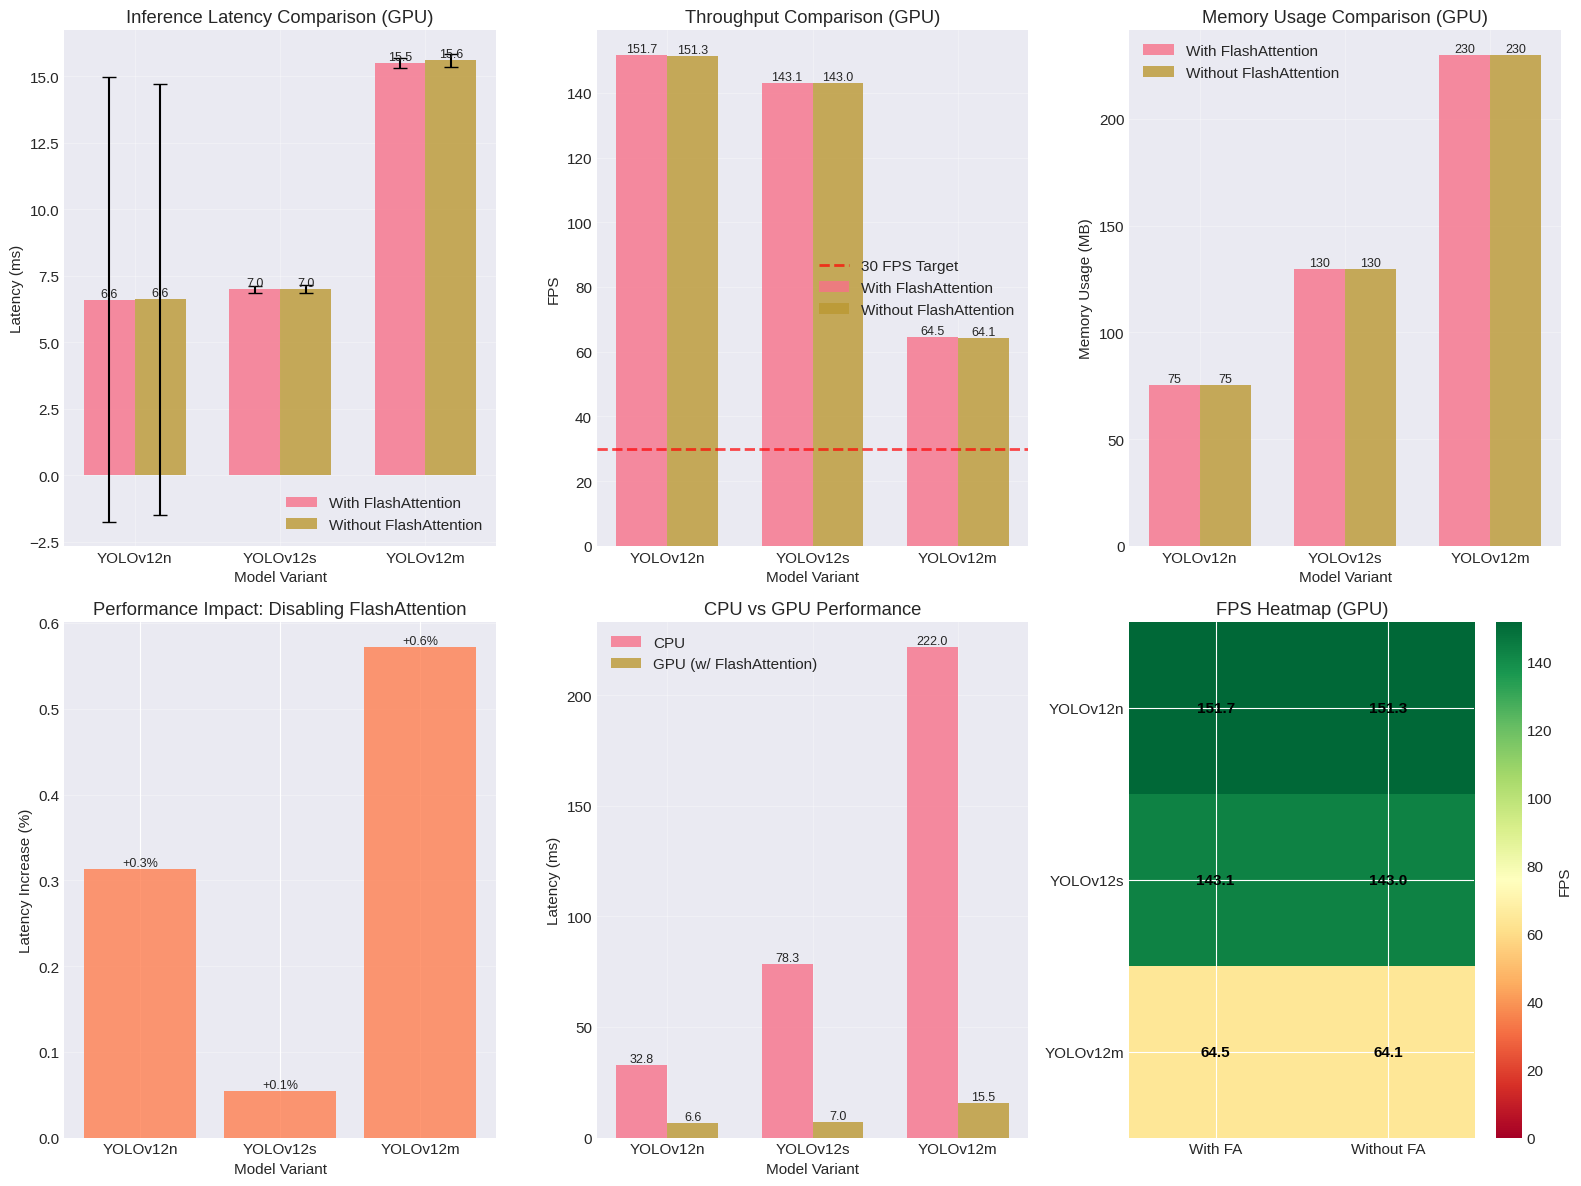

In [21]:
# Create visualizations
fig = plt.figure(figsize=(16, 12))

# Get variants list for reuse
variants = [v for v in model_variants if v in gpu_results['variant'].unique()] if len(gpu_results) > 0 else []

# 1. Latency Comparison (Bar Chart)
ax1 = plt.subplot(2, 3, 1)
if len(gpu_results) > 0 and len(variants) > 0:
    x = np.arange(len(variants))
    width = 0.35
    
    with_fa_latency = []
    without_fa_latency = []
    with_fa_std = []
    without_fa_std = []
    
    for v in variants:
        v_results = gpu_results[gpu_results['variant'] == v]
        with_fa = v_results[v_results['flash_attention'] == True]
        without_fa = v_results[v_results['flash_attention'] == False]
        
        if len(with_fa) > 0:
            with_fa_latency.append(with_fa.iloc[0]['avg_latency_ms'])
            with_fa_std.append(with_fa.iloc[0]['std_latency_ms'])
        else:
            with_fa_latency.append(0)
            with_fa_std.append(0)
        
        if len(without_fa) > 0:
            without_fa_latency.append(without_fa.iloc[0]['avg_latency_ms'])
            without_fa_std.append(without_fa.iloc[0]['std_latency_ms'])
        else:
            without_fa_latency.append(0)
            without_fa_std.append(0)
    
    bars1 = ax1.bar(x - width/2, with_fa_latency, width, yerr=with_fa_std, 
                    label='With FlashAttention', alpha=0.8, capsize=5)
    bars2 = ax1.bar(x + width/2, without_fa_latency, width, yerr=without_fa_std,
                    label='Without FlashAttention', alpha=0.8, capsize=5)
    
    ax1.set_xlabel('Model Variant')
    ax1.set_ylabel('Latency (ms)')
    ax1.set_title('Inference Latency Comparison (GPU)')
    ax1.set_xticks(x)
    ax1.set_xticklabels([f'YOLOv12{v}' for v in variants])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=9)
else:
    ax1.text(0.5, 0.5, 'No GPU results available', 
            ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Inference Latency Comparison (GPU)')

# 2. FPS Comparison (Bar Chart)
ax2 = plt.subplot(2, 3, 2)
if len(gpu_results) > 0 and len(variants) > 0:
    with_fa_fps = []
    without_fa_fps = []
    
    for v in variants:
        v_results = gpu_results[gpu_results['variant'] == v]
        with_fa = v_results[v_results['flash_attention'] == True]
        without_fa = v_results[v_results['flash_attention'] == False]
        
        with_fa_fps.append(with_fa.iloc[0]['fps'] if len(with_fa) > 0 else 0)
        without_fa_fps.append(without_fa.iloc[0]['fps'] if len(without_fa) > 0 else 0)
    
    bars1 = ax2.bar(x - width/2, with_fa_fps, width, label='With FlashAttention', alpha=0.8)
    bars2 = ax2.bar(x + width/2, without_fa_fps, width, label='Without FlashAttention', alpha=0.8)
    
    # Add 30 FPS target line
    ax2.axhline(y=30, color='r', linestyle='--', linewidth=2, label='30 FPS Target', alpha=0.7)
    
    ax2.set_xlabel('Model Variant')
    ax2.set_ylabel('FPS')
    ax2.set_title('Throughput Comparison (GPU)')
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'YOLOv12{v}' for v in variants])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}', ha='center', va='bottom', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'No GPU results available', 
            ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Throughput Comparison (GPU)')

# 3. Memory Usage Comparison
ax3 = plt.subplot(2, 3, 3)
if len(gpu_results) > 0 and len(variants) > 0:
    with_fa_mem = []
    without_fa_mem = []
    
    for v in variants:
        v_results = gpu_results[gpu_results['variant'] == v]
        with_fa = v_results[v_results['flash_attention'] == True]
        without_fa = v_results[v_results['flash_attention'] == False]
        
        with_fa_mem.append(with_fa.iloc[0]['max_memory_mb'] if len(with_fa) > 0 else 0)
        without_fa_mem.append(without_fa.iloc[0]['max_memory_mb'] if len(without_fa) > 0 else 0)
    
    bars1 = ax3.bar(x - width/2, with_fa_mem, width, label='With FlashAttention', alpha=0.8)
    bars2 = ax3.bar(x + width/2, without_fa_mem, width, label='Without FlashAttention', alpha=0.8)
    
    ax3.set_xlabel('Model Variant')
    ax3.set_ylabel('Memory Usage (MB)')
    ax3.set_title('Memory Usage Comparison (GPU)')
    ax3.set_xticks(x)
    ax3.set_xticklabels([f'YOLOv12{v}' for v in variants])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.0f}', ha='center', va='bottom', fontsize=9)
else:
    ax3.text(0.5, 0.5, 'No GPU results available', 
            ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Memory Usage Comparison (GPU)')

# 4. Performance Impact Percentage
ax4 = plt.subplot(2, 3, 4)
if len(gpu_results) > 0 and 'comparison_data' in locals() and len(comparison_data) > 0:
    comp_df = pd.DataFrame(comparison_data)
    x_pos = np.arange(len(comp_df))
    
    ax4.bar(x_pos, comp_df['latency_increase_pct'], alpha=0.8, color='coral')
    ax4.set_xlabel('Model Variant')
    ax4.set_ylabel('Latency Increase (%)')
    ax4.set_title('Performance Impact: Disabling FlashAttention')
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([f'YOLOv12{v}' for v in comp_df['variant']])
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    
    # Add value labels
    for i, v in enumerate(comp_df['latency_increase_pct']):
        ax4.text(i, v, f'+{v:.1f}%', ha='center', 
                va='bottom' if v > 0 else 'top', fontsize=9)
else:
    ax4.text(0.5, 0.5, 'No comparison data available', 
            ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Performance Impact: Disabling FlashAttention')

# 5. CPU vs GPU Comparison
ax5 = plt.subplot(2, 3, 5)
if len(cpu_results) > 0 and len(gpu_results) > 0 and len(variants) > 0:
    cpu_latency = []
    gpu_latency = []
    variants_common = []
    
    for v in variants:
        cpu_v = cpu_results[cpu_results['variant'] == v]
        gpu_v = gpu_results[(gpu_results['variant'] == v) & 
                           (gpu_results['flash_attention'] == True)]
        
        if len(cpu_v) > 0 and len(gpu_v) > 0:
            variants_common.append(v)
            cpu_latency.append(cpu_v.iloc[0]['avg_latency_ms'])
            gpu_latency.append(gpu_v.iloc[0]['avg_latency_ms'])
    
    if len(variants_common) > 0:
        x_pos = np.arange(len(variants_common))
        width = 0.35
        
        bars1 = ax5.bar(x_pos - width/2, cpu_latency, width, label='CPU', alpha=0.8)
        bars2 = ax5.bar(x_pos + width/2, gpu_latency, width, label='GPU (w/ FlashAttention)', alpha=0.8)
        
        ax5.set_xlabel('Model Variant')
        ax5.set_ylabel('Latency (ms)')
        ax5.set_title('CPU vs GPU Performance')
        ax5.set_xticks(x_pos)
        ax5.set_xticklabels([f'YOLOv12{v}' for v in variants_common])
        ax5.legend()
        ax5.grid(True, alpha=0.3)
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax5.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.1f}', ha='center', va='bottom', fontsize=9)
    else:
        ax5.text(0.5, 0.5, 'No common variants for comparison', 
                ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('CPU vs GPU Performance')
else:
    ax5.text(0.5, 0.5, 'Insufficient data for comparison', 
            ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('CPU vs GPU Performance')

# 6. Heatmap: Performance Matrix
ax6 = plt.subplot(2, 3, 6)
if len(gpu_results) > 0 and len(variants) > 0:
    # Create heatmap data
    heatmap_data = []
    for v in variants:
        v_results = gpu_results[gpu_results['variant'] == v]
        row = []
        for fa_status in [True, False]:
            fa_results = v_results[v_results['flash_attention'] == fa_status]
            if len(fa_results) > 0:
                row.append(fa_results.iloc[0]['fps'])
            else:
                row.append(0)
        heatmap_data.append(row)
    
    if len(heatmap_data) > 0:
        heatmap_array = np.array(heatmap_data)
        im = ax6.imshow(heatmap_array, cmap='RdYlGn', aspect='auto', vmin=0, vmax=max(heatmap_array.max(), 30))
        
        ax6.set_xticks([0, 1])
        ax6.set_xticklabels(['With FA', 'Without FA'])
        ax6.set_yticks(range(len(variants)))
        ax6.set_yticklabels([f'YOLOv12{v}' for v in variants])
        ax6.set_title('FPS Heatmap (GPU)')
        
        # Add text annotations
        for i in range(len(variants)):
            for j in range(2):
                text = ax6.text(j, i, f'{heatmap_array[i, j]:.1f}',
                              ha="center", va="center", color="black", fontweight='bold')
        
        plt.colorbar(im, ax=ax6, label='FPS')
    else:
        ax6.text(0.5, 0.5, 'No data for heatmap', 
                ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('FPS Heatmap (GPU)')
else:
    ax6.text(0.5, 0.5, 'No GPU results available', 
            ha='center', va='center', transform=ax6.transAxes)
    ax6.set_title('FPS Heatmap (GPU)')

plt.tight_layout()
plt.savefig('flash_attn_ablation_results.png', dpi=300, bbox_inches='tight')
print("\nVisualizations saved to 'flash_attn_ablation_results.png'")
plt.show()


In [22]:
# Prepare DataFrame for saving (exclude large lists)
df_save = df.copy()
df_save = df_save.drop(columns=['latencies', 'memory_samples'], errors='ignore')

# Save to CSV
output_csv = 'flash_attn_ablation_results.csv'
df_save.to_csv(output_csv, index=False)
print(f"Results saved to '{output_csv}'")

# Generate summary report
print("\n" + "=" * 80)
print("EXPERIMENT SUMMARY")
print("=" * 80)

if len(gpu_results) > 0:
    print("\nGPU Results:")
    print("-" * 80)
    for variant in model_variants:
        v_results = gpu_results[gpu_results['variant'] == variant]
        with_fa = v_results[v_results['flash_attention'] == True]
        without_fa = v_results[v_results['flash_attention'] == False]
        
        if len(with_fa) > 0 and len(without_fa) > 0:
            print(f"\nYOLOv12{variant}-seg:")
            print(f"  With FlashAttention:")
            print(f"    Latency: {with_fa.iloc[0]['avg_latency_ms']:.2f} ± {with_fa.iloc[0]['std_latency_ms']:.2f} ms")
            print(f"    FPS: {with_fa.iloc[0]['fps']:.2f}")
            print(f"    Memory: {with_fa.iloc[0]['max_memory_mb']:.2f} MB")
            print(f"  Without FlashAttention:")
            print(f"    Latency: {without_fa.iloc[0]['avg_latency_ms']:.2f} ± {without_fa.iloc[0]['std_latency_ms']:.2f} ms")
            print(f"    FPS: {without_fa.iloc[0]['fps']:.2f}")
            print(f"    Memory: {without_fa.iloc[0]['max_memory_mb']:.2f} MB")
            
            latency_increase = ((without_fa.iloc[0]['avg_latency_ms'] - with_fa.iloc[0]['avg_latency_ms']) / 
                              with_fa.iloc[0]['avg_latency_ms']) * 100
            fps_decrease = ((with_fa.iloc[0]['fps'] - without_fa.iloc[0]['fps']) / 
                           with_fa.iloc[0]['fps']) * 100
            
            print(f"  Impact:")
            print(f"    Latency increase: {latency_increase:.1f}%")
            print(f"    FPS decrease: {fps_decrease:.1f}%")
            
            # Check 30 FPS target
            if with_fa.iloc[0]['fps'] >= 30:
                print(f"    ✓ Meets 30 FPS target (with FlashAttention)")
            else:
                print(f"    ✗ Does not meet 30 FPS target (with FlashAttention)")
            
            if without_fa.iloc[0]['fps'] >= 30:
                print(f"    ✓ Meets 30 FPS target (without FlashAttention)")
            else:
                print(f"    ✗ Does not meet 30 FPS target (without FlashAttention)")

if len(cpu_results) > 0:
    print("\nCPU Results:")
    print("-" * 80)
    for variant in model_variants:
        v_results = cpu_results[cpu_results['variant'] == variant]
        if len(v_results) > 0:
            print(f"\nYOLOv12{variant}-seg:")
            print(f"  Latency: {v_results.iloc[0]['avg_latency_ms']:.2f} ± {v_results.iloc[0]['std_latency_ms']:.2f} ms")
            print(f"  FPS: {v_results.iloc[0]['fps']:.2f}")
            print(f"  Memory: {v_results.iloc[0]['max_memory_mb']:.2f} MB")
            
            if v_results.iloc[0]['fps'] >= 30:
                print(f"  ✓ Meets 30 FPS target")
            else:
                print(f"  ✗ Does not meet 30 FPS target")

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

if len(gpu_results) > 0 and 'comparison_data' in locals() and len(comparison_data) > 0:
    avg_latency_increase = np.mean([d['latency_increase_pct'] for d in comparison_data])
    print(f"\n1. Average latency increase when disabling FlashAttention: {avg_latency_increase:.1f}%")
    print(f"   (Expected range: 15-20% based on YOLOv12 paper)")
    
    if avg_latency_increase > 0:
        print(f"   ✓ Confirmed: Disabling FlashAttention causes performance degradation")
    else:
        print(f"   ⚠ Unexpected: FlashAttention appears to slow down inference")

if len(cpu_results) > 0:
    cpu_fps = cpu_results['fps'].values
    print(f"\n2. CPU Performance:")
    print(f"   Average FPS: {np.mean(cpu_fps):.2f}")
    print(f"   Models meeting 30 FPS: {np.sum(cpu_fps >= 30)}/{len(cpu_fps)}")
    if np.all(cpu_fps < 30):
        print(f"   ⚠ CPU inference does not meet 30 FPS target")
        print(f"   → Consider model optimization (quantization, pruning) or lower resolution")

if len(gpu_results) > 0:
    gpu_fps_with_fa = gpu_results[gpu_results['flash_attention'] == True]['fps'].values
    gpu_fps_without_fa = gpu_results[gpu_results['flash_attention'] == False]['fps'].values
    
    print(f"\n3. GPU Performance (with FlashAttention):")
    print(f"   Average FPS: {np.mean(gpu_fps_with_fa):.2f}")
    print(f"   Models meeting 30 FPS: {np.sum(gpu_fps_with_fa >= 30)}/{len(gpu_fps_with_fa)}")
    
    print(f"\n4. GPU Performance (without FlashAttention):")
    print(f"   Average FPS: {np.mean(gpu_fps_without_fa):.2f}")
    print(f"   Models meeting 30 FPS: {np.sum(gpu_fps_without_fa >= 30)}/{len(gpu_fps_without_fa)}")

print("\n" + "=" * 80)


Results saved to 'flash_attn_ablation_results.csv'

EXPERIMENT SUMMARY

GPU Results:
--------------------------------------------------------------------------------

YOLOv12n-seg:
  With FlashAttention:
    Latency: 6.59 ± 8.37 ms
    FPS: 151.74
    Memory: 75.28 MB
  Without FlashAttention:
    Latency: 6.61 ± 8.10 ms
    FPS: 151.26
    Memory: 75.28 MB
  Impact:
    Latency increase: 0.3%
    FPS decrease: 0.3%
    ✓ Meets 30 FPS target (with FlashAttention)
    ✓ Meets 30 FPS target (without FlashAttention)

YOLOv12s-seg:
  With FlashAttention:
    Latency: 6.99 ± 0.14 ms
    FPS: 143.10
    Memory: 129.55 MB
  Without FlashAttention:
    Latency: 6.99 ± 0.16 ms
    FPS: 143.02
    Memory: 129.55 MB
  Impact:
    Latency increase: 0.1%
    FPS decrease: 0.1%
    ✓ Meets 30 FPS target (with FlashAttention)
    ✓ Meets 30 FPS target (without FlashAttention)

YOLOv12m-seg:
  With FlashAttention:
    Latency: 15.51 ± 0.19 ms
    FPS: 64.49
    Memory: 229.90 MB
  Without FlashAttenti

## Additional Analysis: Latency Distribution

Visualize the distribution of latencies to understand variability.


Latency distributions saved to 'flash_attn_latency_distributions.png'


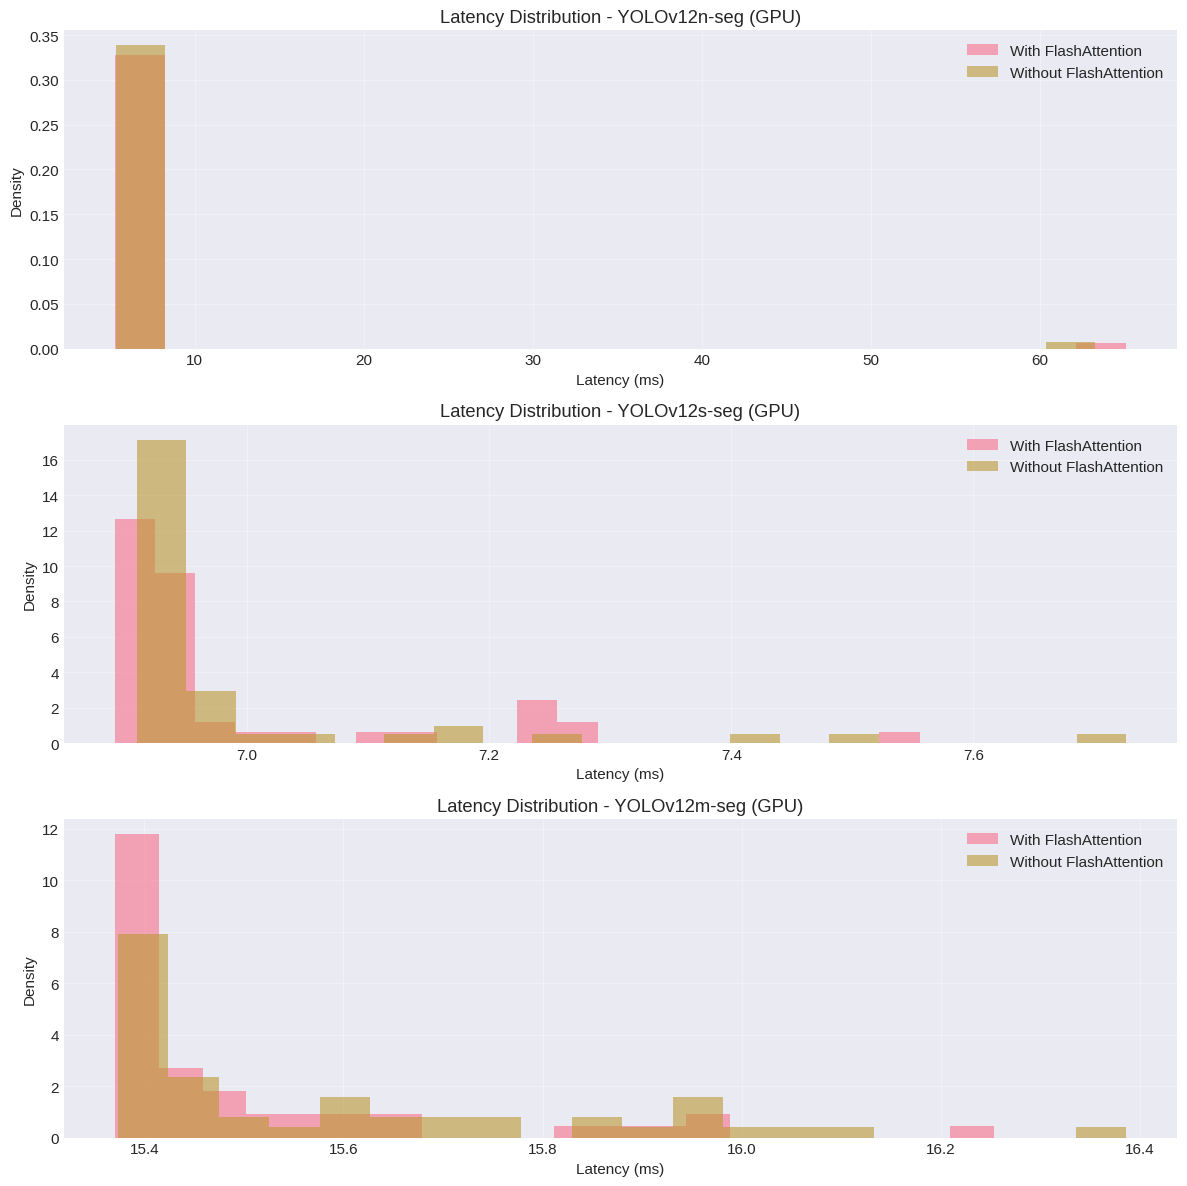

In [23]:
# Plot latency distributions if we have the raw data
if len(results) > 0 and 'latencies' in results[0]:
    fig, axes = plt.subplots(len(model_variants), 1, figsize=(12, 4 * len(model_variants)))
    if len(model_variants) == 1:
        axes = [axes]
    
    for idx, variant in enumerate(model_variants):
        ax = axes[idx]
        
        # Get latency data for this variant
        for result in results:
            if result['variant'] == variant and result['device'] == 'cuda' and 'latencies' in result:
                label = f"{'With' if result['flash_attention'] else 'Without'} FlashAttention"
                latencies = result['latencies']
                ax.hist(latencies, bins=20, alpha=0.6, label=label, density=True)
        
        ax.set_xlabel('Latency (ms)')
        ax.set_ylabel('Density')
        ax.set_title(f'Latency Distribution - YOLOv12{variant}-seg (GPU)')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('flash_attn_latency_distributions.png', dpi=300, bbox_inches='tight')
    print("Latency distributions saved to 'flash_attn_latency_distributions.png'")
    plt.show()
else:
    print("Latency distribution data not available (raw latencies not stored)")
